In [1]:
# Initialize Otter
%pip install otter-grader
import otter
grader = otter.Notebook("DSA_2026_Entry.ipynb")


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## DSA 2026 Summer School Admittance Check

Thanks for your interest in attending DSA Kampala 2026 at Makerere University. To attend the summer school you have to have some level of basic Python proficiency. Completing the following notebook should ensure you have the right kind of background to benefit maximally from the Summer School.
Good luck! See you in Kampala at Makerere University!

In [2]:
# Run these once ... Just in case
#!pip install otter-grader
#!pip install matplotlib scipy  # For machine learning visualization questions
import IPython
from IPython import get_ipython
# Import the good stuff
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
# Note: grader is already initialized in Cell 0 with the notebook path
# Don't reinitialize it here, just use the existing grader

**The Extra Mile!**

This section will test your data analysis skills using real-world economic data from Uganda. You'll work with Consumer Price Index (CPI) data to practice data manipulation, statistical analysis, and time series handling. Good luck!

**Question E1:** Load the Uganda Consumer Price Index dataset from the file `data/uganda-consumer-price-index-trends-2020-2023.xlsx` into a pandas dataframe. Display the first 10 rows and the shape of the dataframe.

In [3]:
import pandas as pd
import numpy as np

# Load the Uganda CPI dataset (Excel file)
df = pd.read_excel(
    r"G:\Other computers\My Laptop\Desktop\PYTHON SANDBOX\DSA_summerschool_notebook\DSA_summerschool_notebook\data\uganda-consumer-price-index-trends-2020-2023.xlsx"
)

# Display first 10 rows and shape
print("Shape of dataframe:", df.shape) # Displaying the shape to understand the dimensions of the data
print("\nFirst 10 rows:")
print(df.head(10)) # Displaying first 10 rows to check the structure of the data


Shape of dataframe: (158, 28)

First 10 rows:
  indicator_code                                        description  \
0         CPI_16  Consumer Price Index (CPI), (2016/17 = 100): A...   
1    CPI_CORE_16  Consumer Price Index (CPI), (2016/17 = 100): C...   
2    CPI_FOOD_16  Consumer Price Index (CPI), (2016/17 = 100): F...   
3     CPI_EFU_16  Consumer Price Index (CPI), (2016/17 = 100): E...   
4         CPI_09  Consumer Price Index (CPI), (2009/10 = 100): A...   
5    CPI_CORE_09  Consumer Price Index (CPI), (2009/10 = 100): C...   
6    CPI_FOOD_09  Consumer Price Index (CPI), (2009/10 = 100): F...   
7     CPI_EFU_09  Consumer Price Index (CPI), (2009/10 = 100): E...   
8         INF_16  Annual (YoY) Inflation (2016/17): All Items In...   
9    INF_CORE_16  Annual (YoY) Inflation (2016/17): Core Index (...   

       dec-20      jan-21      feb-21      mar-21      apr-21      may-21  \
0  111.443410  111.310466  111.846531  112.172433  112.495189  112.668689   
1  112.830685  112

In [4]:
grader.check("e1")

e1 results: All test cases passed!

**Question E2:** Reshape the dataframe from wide format to long format. The monthly columns (dec-20, jan-21, etc.) should become a single 'date' column, and their values should be in a 'value' column. The resulting dataframe should have columns: 'indicator_code', 'description', 'date', and 'value'.

In [5]:
# Reshape dataframe from wide to long format
df_long = pd.melt(
    df,
    id_vars=["indicator_code", "description"],  # columns to keep as identifiers
    var_name="date",                            # name for the new 'date' column
    value_name="value"                          # name for the new 'value' column
)

print("Shape after reshaping:", df_long.shape) # Displaying the shape after reshaping to understand how the data has been transformed
print("\nFirst 10 rows:")
print(df_long.head(10)) # Displaying first 10 rows of the reshaped dataframe to check the new structure


Shape after reshaping: (4108, 4)

First 10 rows:
  indicator_code                                        description    date  \
0         CPI_16  Consumer Price Index (CPI), (2016/17 = 100): A...  dec-20   
1    CPI_CORE_16  Consumer Price Index (CPI), (2016/17 = 100): C...  dec-20   
2    CPI_FOOD_16  Consumer Price Index (CPI), (2016/17 = 100): F...  dec-20   
3     CPI_EFU_16  Consumer Price Index (CPI), (2016/17 = 100): E...  dec-20   
4         CPI_09  Consumer Price Index (CPI), (2009/10 = 100): A...  dec-20   
5    CPI_CORE_09  Consumer Price Index (CPI), (2009/10 = 100): C...  dec-20   
6    CPI_FOOD_09  Consumer Price Index (CPI), (2009/10 = 100): F...  dec-20   
7     CPI_EFU_09  Consumer Price Index (CPI), (2009/10 = 100): E...  dec-20   
8         INF_16  Annual (YoY) Inflation (2016/17): All Items In...  dec-20   
9    INF_CORE_16  Annual (YoY) Inflation (2016/17): Core Index (...  dec-20   

        value  
0  111.443410  
1  112.830685  
2   95.138362  
3  117.355292  
4

In [6]:
grader.check("e2")

e2 results: All test cases passed!

**Question E3:** Convert the 'date' column to datetime format. Handle the date format appropriately (e.g., 'dec-20' should become '2020-12-01', 'jan-21' should become '2021-01-01', etc.).

In [7]:
# Convert date column to datetime
df_long['date'] = pd.to_datetime(df_long['date'], format='%b-%y') #converting the date column to datetime format for easier analysis

print("Date column info:")
print(df_long['date'].head(10)) # Displaying the first 10 entries of the date column to confirm successful conversion to datetime format

print("\nDate range:", df_long['date'].min(), "to", df_long['date'].max()) # Displaying the range of dates in the dataset to understand the time span covered by the data from minimum to maximum date


Date column info:
0   2020-12-01
1   2020-12-01
2   2020-12-01
3   2020-12-01
4   2020-12-01
5   2020-12-01
6   2020-12-01
7   2020-12-01
8   2020-12-01
9   2020-12-01
Name: date, dtype: datetime64[ns]

Date range: 2020-12-01 00:00:00 to 2023-01-01 00:00:00


In [8]:
grader.check("e3")

e3 results: All test cases passed!

**Question E4:** Filter the dataframe to include only CPI indicators (indicator_code starting with 'CPI_'). Create separate dataframes for:
- All Items CPI (CPI_16 and CPI_09)
- Core CPI (CPI_CORE_16 and CPI_CORE_09)
- Food CPI (CPI_FOOD_16 and CPI_FOOD_09)
- Energy Fuel and Utilities CPI (CPI_EFU_16 and CPI_EFU_09)

In [9]:
# Filter for CPI indicators
df_cpi = df_long[df_long['indicator_code'].str.startswith('CPI_')] #selecting only rows where the indicator code starts with 'CPI_' to focus on consumer price index data

# Create separate dataframes
df_all_items = df_cpi[df_cpi['indicator_code'].isin(['CPI_16', 'CPI_09'])] #filtering for all items CPI using specific indicator codes for 2016 and 2009 base years

df_core = df_cpi[df_cpi['indicator_code'].isin(['CPI_CORE_16', 'CPI_CORE_09'])] #filtering for core CPI using specific indicator codes for 2016 and 2009 base years, which typically exclude volatile items like food and energy to provide a clearer view of underlying inflation trends

df_food = df_cpi[df_cpi['indicator_code'].isin(['CPI_FOOD_16', 'CPI_FOOD_09'])] #filtering for food CPI using specific indicator codes for 2016 and 2009 base years, which focuses on the price changes of food items to analyze their contribution to overall inflation
 
df_efu = df_cpi[df_cpi['indicator_code'].isin(['CPI_EFU_16', 'CPI_EFU_09'])] #filtering for EFU CPI using specific indicator codes for 2016 and 2009 base years, which typically includes energy, food, and unprocessed items to analyze their combined impact on inflation

print("All Items CPI shape:", df_all_items.shape)
print("Core CPI shape:", df_core.shape)
print("Food CPI shape:", df_food.shape)
print("EFU CPI shape:", df_efu.shape)


All Items CPI shape: (52, 4)
Core CPI shape: (52, 4)
Food CPI shape: (52, 4)
EFU CPI shape: (52, 4)


In [10]:
grader.check("e4")

e4 results: All test cases passed!

**Question E5:** Check for missing values in the 'value' column. If there are any missing values, replace them with the median value of that specific indicator_code. Display the count of missing values before and after replacement.

In [11]:
# Check for missing values
missing_before = df_long['value'].isna().sum() # Counting the number of missing values in the 'value' column before replacement to understand the extent of missing data in the dataset
print("Missing values before replacement:", missing_before)

# Replace missing values with median per indicator_code
df_long['value'] = df_long['value'].fillna(
    df_long.groupby('indicator_code')['value'].transform('median')
)

# Check again
missing_after = df_long['value'].isna().sum()
print("Missing values after replacement:", missing_after)


Missing values before replacement: 0
Missing values after replacement: 0


In [12]:
grader.check("e5")

e5 results: All test cases passed!

## Natural Language Processing and Large Language Models

**Question N1:** Write a function `count_words` that takes a text string as input and returns a dictionary where keys are unique words (lowercased) and values are their frequencies. Ignore punctuation and split on whitespace.

Example: `count_words("Hello world hello")` should return `{'hello': 2, 'world': 1}`

In [13]:
import string

def count_words(text):
    """
    Count word frequencies in a text string.

    Parameters:
    text (str): Input text string

    Returns:
    dict: Dictionary with words as keys and frequencies as values
    """
    
    # Convert to lowercase
    text = text.lower() # Converting the text to lowercase to ensure that word counting is case-insensitive, so that 'Data' and 'data' are counted as the same word.
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation)) # Removing punctuation from the text to ensure that words are counted correctly without being affected by punctuation marks, so that 'data,' and 'data' are counted as the same word.
    
    # Split on whitespace
    words = text.split() # Splitting the text into words based on whitespace to create a list of individual words for counting their frequencies.
    
    # Count frequencies
    word_counts = {} # Initializing an empty dictionary to store word counts, where keys will be unique words and values will be their corresponding frequencies.
    for word in words: # Iterating through each word in the list of words to count their frequencies.
        word_counts[word] = word_counts.get(word, 0) + 1 # Using the get method to retrieve the current count of the word from the dictionary, defaulting to 0 if the word is not yet in the dictionary, and then incrementing it by 1 for each occurrence of the word.
    
    return word_counts # Returning the dictionary containing words and their corresponding frequencies as the output of the function.


# Test the function
test_text = "Data Science Africa 2026 is happening in Kampala at Makerere University. Makerere University is a great place for learning."
result = count_words(test_text)
print(result)


{'data': 1, 'science': 1, 'africa': 1, '2026': 1, 'is': 2, 'happening': 1, 'in': 1, 'kampala': 1, 'at': 1, 'makerere': 2, 'university': 2, 'a': 1, 'great': 1, 'place': 1, 'for': 1, 'learning': 1}


In [14]:
grader.check("n1")

n1 results: All test cases passed!

**Question N2:** Write a function `extract_entities` that takes a text string and a list of entity keywords, and returns a list of sentences that contain any of those keywords. This simulates basic named entity recognition.

Example:
- Text: "Makerere University is in Kampala. Kampala is the capital of Uganda."
- Keywords: ["Makerere", "Kampala"]
- Should return: ["Makerere University is in Kampala.", "Kampala is the capital of Uganda."]

In [15]:
import re

def extract_entities(text, keywords):
    """
    Extract sentences containing specified keywords.

    Parameters:
    text (str): Input text string
    keywords (list): List of keywords to search for

    Returns:
    list: List of sentences containing the keywords
    """
    
    # Split text into sentences using regex (handles ., !, ?)
    sentences = re.split(r'(?<=[.!?])\s+', text.strip()) # Splitting the text into sentences using regular expressions to handle different sentence-ending punctuation marks (., !, ?) and ensuring that sentences are properly separated based on whitespace after the punctuation.
    
    # Make keywords lowercase for case-insensitive matching
    keywords_lower = [kw.lower() for kw in keywords] # Converting the list of keywords to lowercase to enable case-insensitive matching when searching for keywords in sentences.
    
    matching_sentences = [] # Initializing an empty list to store sentences that contain any of the specified keywords.
    
    for sentence in sentences: # Iterating through each sentence in the list of sentences to check for the presence of keywords.
        sentence_lower = sentence.lower() # Converting the sentence to lowercase for case-insensitive comparison with keywords.
        if any(keyword.lower() in sentence_lower for keyword in keywords_lower): # Checking if any of the keywords are present in the sentence (case-insensitive) and if so, adding the original sentence (stripped of leading/trailing whitespace) to the list of matching sentences.
            matching_sentences.append(sentence.strip()) # Adding the original sentence (stripped of leading/trailing whitespace) to the list of matching sentences if any keyword is found in the sentence.
    
    return matching_sentences # Returning the list of sentences that contain any of the specified keywords as the output of the function.


# Test the function
test_text = "DSA 2026 will be held at Makerere University in Kampala. Kampala is a beautiful city. Makerere University is one of the oldest universities in Africa."
keywords = ["Makerere", "Kampala", "DSA"]
result = extract_entities(test_text, keywords)
print(result)


['DSA 2026 will be held at Makerere University in Kampala.', 'Kampala is a beautiful city.', 'Makerere University is one of the oldest universities in Africa.']


In [16]:
grader.check("n2")

n2 results: All test cases passed!

**Question N3:** Write a function `calculate_similarity` that takes two text strings and calculates their similarity based on the Jaccard similarity of their word sets. Jaccard similarity is the size of the intersection divided by the size of the union of two sets.

Formula: J(A, B) = |A ∩ B| / |A ∪ B|

Example:
- Text1: "data science africa"
- Text2: "data science kampala"
- Should return approximately 0.67 (2 common words / 3 unique words)

In [17]:
import string

def calculate_similarity(text1, text2):
    """
    Calculate Jaccard similarity between two text strings.

    Parameters:
    text1 (str): First text string
    text2 (str): Second text string

    Returns:
    float: Jaccard similarity score between 0 and 1
    """

    # Convert texts to sets of lowercase words
    set1 = set(text1.lower().split()) # Converting the first text to lowercase and splitting it into a set of unique words for Jaccard similarity calculation.
    set2 = set(text2.lower().split()) # Converting the second text to lowercase and splitting it into a set of unique words for Jaccard similarity calculation.

    # Find intersection and union
    intersection = set1.intersection(set2) # Finding the intersection of the two sets to identify common words between the two texts for Jaccard similarity calculation.
    union = set1.union(set2) # Finding the union of the two sets to identify all unique words present in either of the two texts for Jaccard similarity calculation.

    # Avoid division by zero
    if len(union) == 0: # If both texts are empty, the union will be empty, and we can define similarity as 0 in this case to avoid division by zero errors.
        return 0.0    # Returning a similarity score of 0.0 when both texts are empty to indicate no similarity.

    similarity = len(intersection) / len(union) # Calculating the Jaccard similarity score by dividing the size of the intersection by the size of the union of the two sets of words.

    return similarity # Returning the Jaccard similarity score as the output of the function.


# Test the function
text1 = "Data Science Africa 2026 Kampala Makerere University"
text2 = "Data Science Africa Kampala Makerere"

similarity = calculate_similarity(text1, text2) # Calculating the Jaccard similarity score between the two test texts to evaluate how similar they are based on their unique word content.
print(f"Similarity: {similarity:.4f}") # Printing the similarity score formatted to 4 decimal places to provide a clear and concise representation of the Jaccard similarity between the two texts.

Similarity: 0.7143


In [18]:
grader.check("n3")

n3 results: All test cases passed!

## Machine Learning and Data Visualization

This section introduces you to data visualization and basic machine learning concepts using 2D classification data.

**Question M1:** Load the dataset from `data/data-2class.npz`. This file contains a set of 2-dimensional points `d` (shape: 1000x2), and a corresponding set of labels `l` (shape: 1000x1). Create a 2D scatterplot of the points, using red for elements with label 0, and blue for elements with label 1.

**Hint:** Use matplotlib for plotting. The dataset keys are 'd' for data points and 'l' for labels.

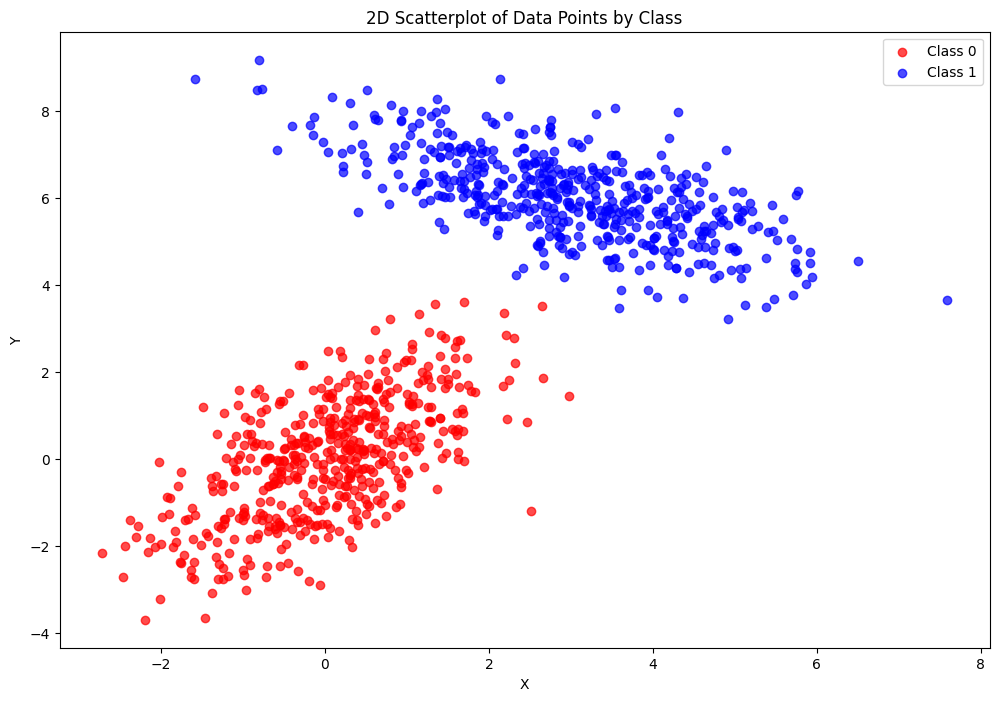

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
data = np.load(r"G:\Other computers\My Laptop\Desktop\PYTHON SANDBOX\DSA_summerschool_notebook\DSA_summerschool_notebook\data\data-2class.npz")

# Extract points and labels
d = data['d']  # extracting the 2D data points from the loaded dataset, where 'd' contains the coordinates of the points in a shape of (1000, 2) representing 1000 samples with 2 features (x and y coordinates).
l = data['l'].flatten()  # extracting the labels from the dataset and flattening them to a 1D array, where 'l' contains the class labels for each of the 1000 samples, indicating which class each point belongs to (e.g., 0 or 1 for binary classification).

# Create scatterplot
plt.figure(figsize=(12,8)) # Setting the figure size to 12 inches by 8 inches for better visibility of the scatter plot.
plt.scatter(d[l == 0, 0], d[l == 0, 1], color='red', label='Class 0', alpha=0.7) # Plotting the data points belonging to Class 0 in red color with some transparency (alpha=0.7) for better visualization when points overlap.
plt.scatter(d[l == 1, 0], d[l == 1, 1], color='blue', label='Class 1', alpha=0.7) # Plotting the data points belonging to Class 1 in blue color with some transparency (alpha=0.7) for better visualization when points overlap.

plt.xlabel('X')
plt.ylabel('Y')
plt.title('2D Scatterplot of Data Points by Class')
plt.legend()
plt.show()


In [20]:
grader.check("m1")

m1 results: All test cases passed!

**Question M2:** Draw a straight line separating the two classes on the scatterplot. The line should visually separate the red points (label 0) from the blue points (label 1). You can choose the line parameters (slope and intercept) manually - the purpose is to think about how this line could be used to classify the data.

**Hint:** You can use `plt.plot()` or `plt.axline()` to draw a line. Think about where the line should be positioned to best separate the two classes.

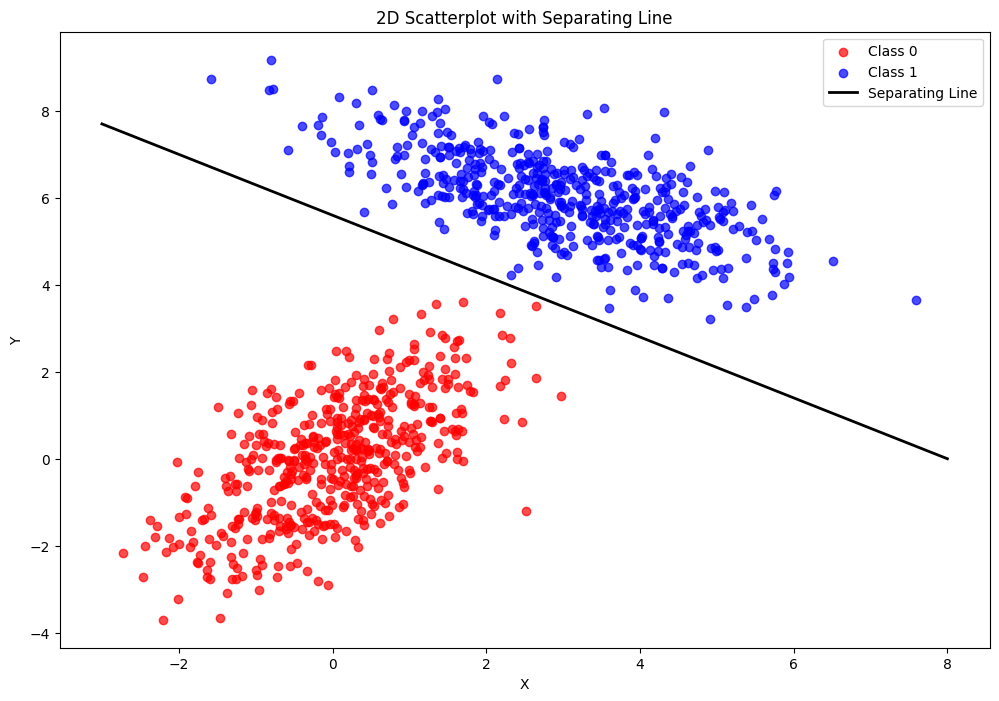

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
data = np.load(r"G:\Other computers\My Laptop\Desktop\PYTHON SANDBOX\DSA_summerschool_notebook\DSA_summerschool_notebook\data\data-2class.npz")
d = data['d']
l = data['l'].flatten()

# Recreate the scatterplot
plt.figure(figsize=(12,8))
plt.scatter(d[l == 0, 0], d[l == 0, 1], color='red', label='Class 0', alpha=0.7) # Plotting the data points belonging to Class 0 in red color with some transparency (alpha=0.7) for better visualization when points overlap.
plt.scatter(d[l == 1, 0], d[l == 1, 1], color='blue', label='Class 1', alpha=0.7) # Plotting the data points belonging to Class 1 in blue color with some transparency (alpha=0.7) for better visualization when points overlap.

# Draw a separating line
# Example: line y = m*x + b
x_space = np.linspace(-3, 8, 100) # Generating 100 evenly spaced x values from -3 to 8 to plot the separating line across the range of the data points.
y_space = -0.7 * x_space + 5.6 # Calculating the corresponding y values for the separating line using the equation of the line (y = mx + b) with a slope of -0.7 and an intercept of 5.6, which is chosen to visually separate the two classes in the scatter plot.

plt.plot(x_space, y_space, color='black', linewidth=2, label='Separating Line') # Plotting the separating line on the scatter plot with black color and a linewidth of 2 for better visibility, and adding a label for the legend.

plt.xlabel('X')
plt.ylabel('Y')
plt.title('2D Scatterplot with Separating Line')
plt.legend()
plt.show()


In [22]:
grader.check("m2")

m2 results: All test cases passed!

**Question M3:** Fit two 2D Gaussian distributions to the points with label $l_i=0$ and $l_i=1$. For each class, calculate:
- The mean (centroid) of the points
- The covariance matrix

**Hint:** Use NumPy to calculate the mean and covariance. For class 0, filter points where `l == 0`, and for class 1, filter points where `l == 1`.

In [23]:
import numpy as np

# Load the dataset
data = np.load("G:\Other computers\My Laptop\Desktop\PYTHON SANDBOX\DSA_summerschool_notebook\DSA_summerschool_notebook\data\data-2class.npz")
d = data['d']
l = data['l'].flatten()  # Flatten labels to 1D

# Filter points by label
points_class_0 = d[l == 0]  # points with label 0
points_class_1 = d[l == 1]  # points with label 1

# Calculate mean (centroid) for each class
mean_class_0 = np.mean(points_class_0, axis=0) # Calculating the mean (centroid) of the points belonging to Class 0 by taking
mean_class_1 = np.mean(points_class_1, axis=0) # Calculating the mean (centroid) of the points belonging to Class 1 by taking

# Calculate covariance matrix for each class
cov_class_0 = np.cov(points_class_0, rowvar=False)  # rowvar=False since columns are variables
cov_class_1 = np.cov(points_class_1, rowvar=False) # Calculating the covariance matrix for Class 1 using the np.cov function, where rowvar=False indicates that the variables are represented by columns in the input data.

# Display results
print("Class 0:")
print(f"  Mean: {mean_class_0}")
print(f"  Covariance:\n{cov_class_0}")

print("\nClass 1:")
print(f"  Mean: {mean_class_1}")
print(f"  Covariance:\n{cov_class_1}")


Class 0:
  Mean: [0.0246913  0.02217358]
  Covariance:
[[1.0082275  0.89013228]
 [0.89013228 1.9444243 ]]

Class 1:
  Mean: [2.98632697 6.0252646 ]
  Covariance:
[[ 1.98591055 -0.92629917]
 [-0.92629917  1.02294045]]


In [24]:
grader.check("m3")

m3 results: All test cases passed!

**Question M4:** Create a heatmap plotting the two Gaussian distributions and superimpose a scatterplot of the data points. 

**Hint:** 
- Use `scipy.stats.multivariate_normal` to create the Gaussian distributions
- Create a meshgrid for the heatmap
- Use `plt.contour()` or `plt.contourf()` for the heatmap
- Overlay the scatterplot on top

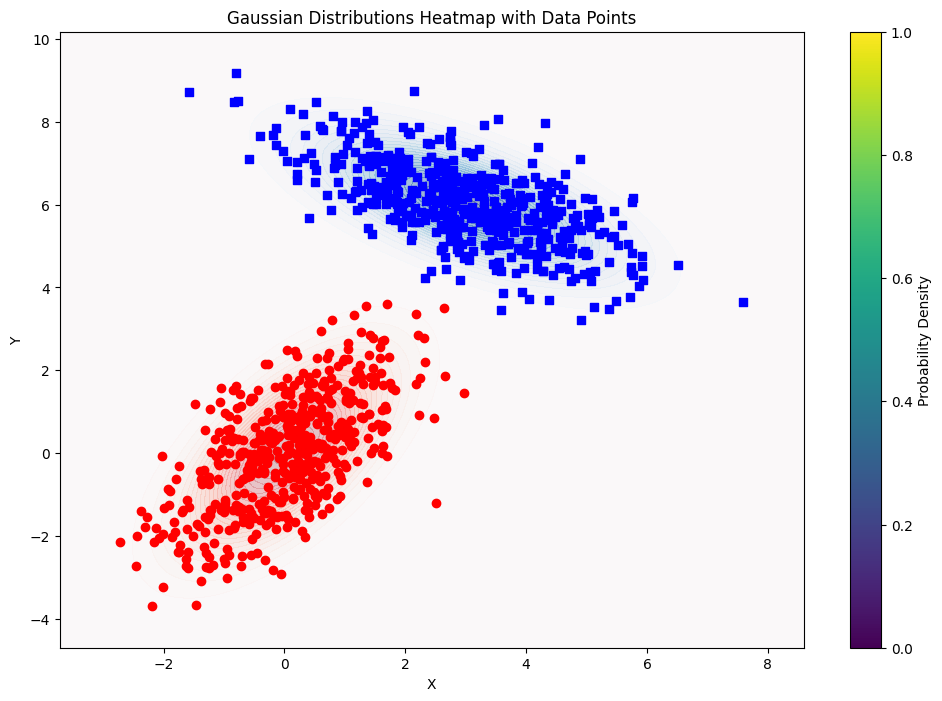

In [25]:
from scipy.stats import multivariate_normal
import matplotlib.pyplot as plt
import numpy as np

# Create meshgrid for heatmap
x_min, x_max = d[:, 0].min() - 1, d[:, 0].max() + 1
y_min, y_max = d[:, 1].min() - 1, d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

# Create Gaussian distributions
gaussian_class_0 = multivariate_normal(mean_class_0, cov_class_0)
gaussian_class_1 = multivariate_normal(mean_class_1, cov_class_1)

# Calculate probability density for each point in meshgrid
pos = np.dstack((xx, yy))
pdf_class_0 = gaussian_class_0.pdf(pos)
pdf_class_1 = gaussian_class_1.pdf(pos)

# Create heatmap (contour plot)
plt.figure(figsize=(12,8))

plt.contourf(xx, yy, pdf_class_0,
             levels=25, cmap='Reds', alpha=0.4)

plt.contourf(xx, yy, pdf_class_1,
             levels=25, cmap='Blues', alpha=0.4)

# Superimpose scatterplot
plt.scatter(points_class_0[:,0], points_class_0[:,1], c='red', marker='o', label='Class 0')
plt.scatter(points_class_1[:,0], points_class_1[:,1], c='blue', marker='s', label='Class 1')


plt.xlabel('X')

plt.ylabel('Y')
plt.title('Gaussian Distributions Heatmap with Data Points')
plt.colorbar(label='Probability Density')
plt.show()

In [26]:
grader.check("m4")

m4 results: All test cases passed!

## Submission Instructions

### Before Submitting:

1. **Run all cells in order** - Make sure you've executed every cell from top to bottom. This ensures all your solutions are saved and any outputs are included.

2. **Check all tests pass** - Verify that all `grader.check()` cells show that tests pass. If any fail, fix your code and re-run.

3. **Save your notebook** - Use File → Save (or Cmd+S / Ctrl+S) to save all your work.

4. **Verify your solutions** - Double-check that:
   - All `...` placeholders have been replaced with your code
   - All functions are properly implemented
   - Data analysis questions produce expected outputs
   - NLP functions work with the test cases

### Submitting:

1. **Run the cell below** - This will generate a `.zip` file containing your completed notebook.

2. **Find the zip file** - It will be created in the same directory as this notebook, typically named something like `DSA_2026_Entry.zip` or similar.

3. **Upload to application portal** - Upload the generated zip file to:
   - The Google Sheet link provided in the application instructions, OR
   - The application portal/website as specified

4. **Keep a backup** - Save a copy of your completed notebook for your records.

### Important Reminders:

- ⚠️ **All work must be your own** - Uploading work that is not yours will lead to non-admittance to DSA 2026 Kampala at Makerere University.
- ✅ Make sure the zip file contains your completed notebook with all solutions
- ✅ Do not modify the test files or grader setup
- ✅ Include the `data/` folder if required by the submission instructions

**Ready to submit? Run the cell below!**

In [27]:
#Save your notebook first, then run this cell to export your submission.grader.export(run_tests=True)

In [29]:
grader.export(run_tests=True)

c:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\otter\check\notebook.py:494: UserWarning: Could not locate a PDF to include
  warnings.warn("Could not locate a PDF to include")


UnicodeDecodeError: 'charmap' codec can't decode byte 0x8f in position 443811: character maps to <undefined>